# K06 — A land-cover map, trained on ESA WorldCover

K01–K05 compared fingerprints directly. This is the first notebook that
**trains a model**: the workflow TESSERA is built for, where the embeddings are
the input and a small, simple classifier sits on top.

The labels come from **ESA WorldCover 2021**, a free global 10 m land-cover map
with the same pixel size as TESSERA. The question is: from the embeddings
alone, can a linear classifier reproduce WorldCover's classes in a part of
Kenya **it has never seen**?

**The answer key is not the truth.** WorldCover has its own errors. Globally it
is 76.7% accurate ([validation report](https://esa-worldcover.s3.eu-central-1.amazonaws.com/v200/2021/docs/WorldCover_PVR_V2.0.pdf)).
For **cropland in Kenya** specifically, an independent study found its 2020
version had precision 0.61 but recall only **0.34**: it missed about two-thirds
of Kenyan cropland ([Kerner et al., 2024](https://arxiv.org/abs/2307.02575)). So
this notebook measures **agreement with WorldCover**, not accuracy, and where
the two disagree about cropland, either could be wrong.

**Downloads:** no embeddings. All 24 tiles are already cached for 2021 (see
`K.CACHED_REGIONS`). The WorldCover labels, 3.5 MB, come from
[`data/fetch_worldcover.py`](../data/fetch_worldcover.py).

In [1]:
# ---------------------------------------------------------------------------
# SETUP
# ---------------------------------------------------------------------------
import sys
from pathlib import Path

import numpy as np                    # array maths
import pandas as pd                   # tables
import matplotlib.pyplot as plt       # every figure below
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
import rasterio
from rasterio.warp import Resampling, reproject
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Jupyter may start in the repo root or in experiments/. Locate src/kenya.py
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "src" / "kenya.py").is_file()),
    None,
)
if repo_root is None:
    raise RuntimeError("Could not locate the repository root containing src/kenya.py")
sys.path.insert(0, str(repo_root / "src"))

import kenya as K           # shared helpers for this series — see src/kenya.py

gt = K.client()
YEAR = 2021                            # WorldCover v200's year
REGIONS = K.CACHED_REGIONS
print(f"{len(REGIONS)} regions, {sum(len(t) for t in REGIONS.values())} tiles")

11 regions, 24 tiles


## 1. The labels

WorldCover's classes, with its own colours. Snow, mangroves and moss/lichen do
not occur in these tiles, so eight classes remain.

Each tile's WorldCover window is copied onto the tile's own 10 m grid (nearest
neighbour), so every embedding pixel gets exactly one label.

In [2]:
# ---------------------------------------------------------------------------
# WORLDCOVER CLASSES, AND LABELS ON EACH TILE'S GRID
# ---------------------------------------------------------------------------
CLASSES = {10: ("tree cover", "#006400"), 20: ("shrubland", "#ffbb22"),
           30: ("grassland", "#ffff4c"), 40: ("cropland", "#f096ff"),
           50: ("built-up", "#fa0000"), 60: ("bare / sparse", "#b4b4b4"),
           80: ("water", "#0064c8"), 90: ("wetland", "#0096a0")}
CODES = list(CLASSES)
NAMES = [CLASSES[c][0] for c in CODES]
CMAP = ListedColormap(["white"] + [CLASSES[c][1] for c in CODES])   # index 0 = no label

def labels_on_grid(lon, lat, crs, transform, shape):
    """WorldCover codes on a TESSERA tile's pixel grid."""
    out = np.zeros(shape, np.uint8)
    with rasterio.open(repo_root / "data" / "worldcover_2021" / f"wc_{lon:.2f}_{lat:.2f}.tif") as src:
        reproject(src.read(1), out, src_transform=src.transform, src_crs=src.crs,
                  dst_transform=transform, dst_crs=crs, resampling=Resampling.nearest)
    return out

def to_index(codes):
    """WorldCover code -> 1..8 for plotting (0 where there is no label)."""
    lookup = np.zeros(256, np.uint8)
    lookup[CODES] = np.arange(1, len(CODES) + 1)
    return lookup[codes]

## 2. Training and test pixels

Neighbouring pixels are nearly identical, so testing on pixels next to the
training pixels would be far too easy. The fair test holds out **a whole
region**: train on 10 regions, predict the 11th, and repeat for every region.
Lake Baringo's nine tiles count as one region, as do Konza's three and the
escarpment's four, so no test tile has a neighbour in training.

From each tile:

- **training:** up to 1,500 pixels per class, so rare classes (built-up,
  wetland) are not drowned out by grassland and shrubland;
- **testing:** 50,000 pixels drawn at random, so test results reflect how common
  each class really is.

In [3]:
# ---------------------------------------------------------------------------
# SAMPLE PIXELS FROM EVERY TILE
# ---------------------------------------------------------------------------
rng = np.random.default_rng(0)
PER_CLASS, TEST_PER_TILE = 1500, 50_000

train, test = {}, {}
for region, tiles in REGIONS.items():
    Xtr, ytr, Xte, yte = [], [], [], []
    for lon, lat in tiles:
        emb, crs, transform = K.fetch(gt, lon, lat, YEAR)
        h, w, d = emb.shape
        y = labels_on_grid(lon, lat, crs, transform, (h, w)).ravel()
        X = emb.reshape(-1, d)
        usable = np.nonzero(K.valid_mask(emb).ravel() & np.isin(y, CODES))[0]
        for c in CODES:
            pool = usable[y[usable] == c]
            if len(pool):
                pick = rng.choice(pool, min(PER_CLASS, len(pool)), replace=False)
                Xtr.append(X[pick]); ytr.append(y[pick])
        pick = rng.choice(usable, min(TEST_PER_TILE, len(usable)), replace=False)
        Xte.append(X[pick]); yte.append(y[pick])
        del emb, X
    train[region] = (np.concatenate(Xtr), np.concatenate(ytr))
    test[region] = (np.concatenate(Xte), np.concatenate(yte))

shares = pd.DataFrame({r: pd.Series(test[r][1]).value_counts(normalize=True) for r in REGIONS}).T
shares = shares.reindex(columns=CODES).fillna(0).rename(columns=dict(zip(CODES, NAMES)))
print("WorldCover's classes in each region (share of test pixels):\n")
print(shares.to_string(float_format=lambda v: f"{v:5.0%}"))

WorldCover's classes in each region (share of test pixels):

                 tree cover  shrubland  grassland  cropland  built-up  bare / sparse  water  wetland
Kitale maize            17%        13%        17%       47%        5%             0%     0%       0%
Kericho tea             64%        26%         7%        1%        3%             0%     0%       0%
Mwea rice               17%         4%         2%       67%        5%             0%     0%       5%
Nairobi                 31%         8%         7%        3%       50%             1%     0%       0%
Mau Forest              84%        11%         4%        0%        0%             0%     0%       0%
Maasai Mara              2%         2%        96%        0%        0%             0%     0%       0%
Marsabit desert          0%         1%        35%        0%        0%            64%     0%       0%
Uasin Gishu             15%        23%        20%       41%        0%             0%     0%       0%
Lake Baringo            12%   

One row stands out before any model is trained: **Kericho, the tea belt, is 64%
tree cover and 1% cropland in WorldCover.** WorldCover does not count tea as a
crop. So a model trained on WorldCover can never map tea as cropland, whatever
the embeddings contain. (K05 found tea directly, from OSM fields.)

## 3. Train on ten regions, test on the eleventh

The classifier is **logistic regression**: a linear model, with the 128
embedding values standardised. It is deliberately simple. If a linear model
does well, the information is in the embeddings, not in a clever classifier.

In [4]:
# ---------------------------------------------------------------------------
# LEAVE-ONE-REGION-OUT
# ---------------------------------------------------------------------------
def fit(regions):
    X = np.concatenate([train[r][0] for r in regions])
    y = np.concatenate([train[r][1] for r in regions])
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=500)).fit(X, y)

models, preds, rows = {}, {}, []
for held in REGIONS:
    models[held] = fit([r for r in REGIONS if r != held])
    yt = test[held][1]
    p = models[held].predict(test[held][0])
    preds[held] = p
    crop_pred, crop_true = p == 40, yt == 40
    rows.append({"region": held,
                 "agreement": accuracy_score(yt, p),
                 "cropland_wc": crop_true.mean(),
                 "cropland_model": crop_pred.mean()})

per_region = pd.DataFrame(rows).set_index("region")
y_all = np.concatenate([test[r][1] for r in REGIONS])
p_all = np.concatenate([preds[r] for r in REGIONS])
print(per_region[["agreement"]].to_string(float_format=lambda v: f"{v:6.1%}"))
print(f"\nall held-out pixels: agreement {accuracy_score(y_all, p_all):.1%}, "
      f"macro F1 {f1_score(y_all, p_all, labels=CODES, average='macro'):.2f}")
per_class = pd.Series(f1_score(y_all, p_all, labels=CODES, average=None), index=NAMES)
print("\nF1 per class:\n" + per_class.to_string(float_format=lambda v: f"{v:.2f}"))

                 agreement
region                    
Kitale maize         76.1%
Kericho tea          66.9%
Mwea rice            55.8%
Nairobi              73.0%
Mau Forest           88.5%
Maasai Mara          94.6%
Marsabit desert      58.1%
Uasin Gishu          63.7%
Lake Baringo         60.1%
Konza                89.7%
Rift escarpment      65.2%

all held-out pixels: agreement 68.6%, macro F1 0.61

F1 per class:
tree cover      0.69
shrubland       0.62
grassland       0.76
cropland        0.67
built-up        0.55
bare / sparse   0.55
water           0.88
wetland         0.18


**68.6% agreement with WorldCover in regions the model never saw**, macro F1
0.61, from a linear model. For scale, WorldCover itself is 76.7% accurate
globally, so some of the disagreement is WorldCover's error, not the model's.

Agreement is highest where one class dominates (Maasai Mara 95%, Konza 90%,
Mau 89%) and lowest in mixed landscapes: Mwea 56%, Marsabit 58%, Baringo 60%.
Water is the easiest class (F1 0.88) and wetland the hardest (0.18); wetland is
only 0.3% of the test pixels, mostly at Mwea.

**Why hold out whole regions?** For comparison, the same model tested the easy
way: training and test pixels drawn from the *same* tiles. The gap between the
two numbers is how much a careless test would flatter the result.

In [5]:
# ---------------------------------------------------------------------------
# THE EASY TEST, FOR CONTRAST: same tiles for training and testing
# ---------------------------------------------------------------------------
same_tiles = fit(list(REGIONS))
p_easy = np.concatenate([same_tiles.predict(test[r][0]) for r in REGIONS])
print(f"test pixels from the training tiles:   agreement {accuracy_score(y_all, p_easy):.1%}")
print(f"test pixels from an unseen region:     agreement {accuracy_score(y_all, p_all):.1%}")

test pixels from the training tiles:   agreement 72.9%
test pixels from an unseen region:     agreement 68.6%


The gap is **4.3 points** (72.9% vs 68.6%). That is smaller than it often is,
because a linear model cannot memorise individual places. But it is the
honest number: 68.6% is what to expect in a part of Kenya with no training
data.

## 4. Where does it disagree with WorldCover?

Each row is a WorldCover class; each row sums to 100%, so the diagonal is the
share of that class the model agrees with, and off-diagonal cells show where
the rest went.

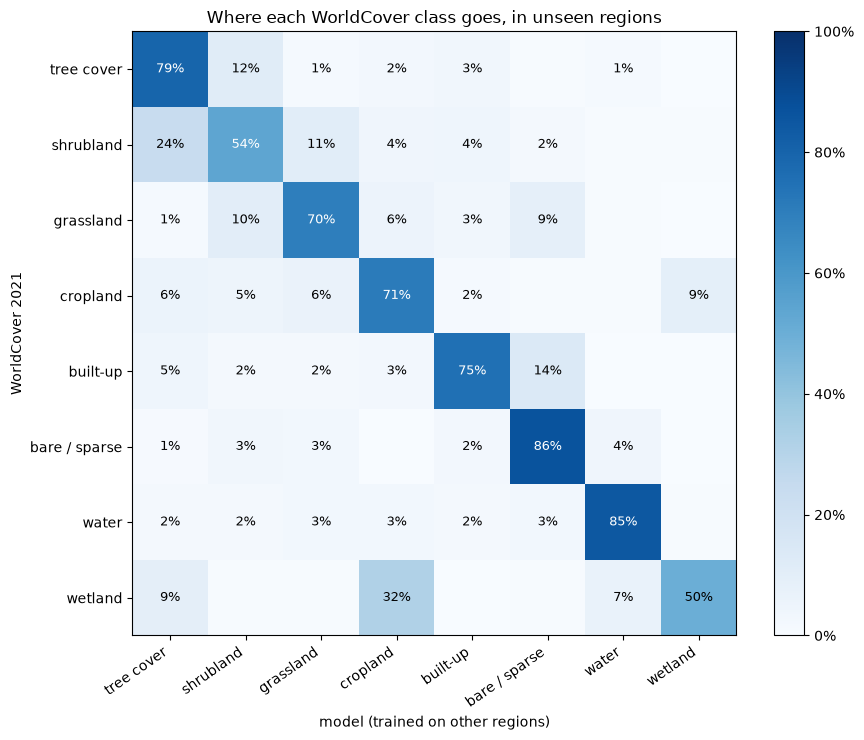

In [6]:
# ---------------------------------------------------------------------------
# CONFUSION MATRIX (rows = WorldCover, columns = model), held-out regions
# ---------------------------------------------------------------------------
cm = confusion_matrix(y_all, p_all, labels=CODES, normalize="true")
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
for i in range(len(CODES)):
    for j in range(len(CODES)):
        if cm[i, j] >= 0.01:
            ax.text(j, i, f"{cm[i, j]:.0%}", ha="center", va="center", fontsize=9,
                    color="white" if cm[i, j] > 0.5 else "black")
ax.set_xticks(range(len(CODES))); ax.set_xticklabels(NAMES, rotation=35, ha="right")
ax.set_yticks(range(len(CODES))); ax.set_yticklabels(NAMES)
ax.set_xlabel("model (trained on other regions)"); ax.set_ylabel("WorldCover 2021")
ax.set_title("Where each WorldCover class goes, in unseen regions", fontsize=12)
fig.colorbar(im, ax=ax, fraction=0.046, format=PercentFormatter(1.0))
plt.tight_layout(); plt.show()

Most classes agree 70–86% of the time. The two weak spots are both classes
that are a matter of degree:

- **Shrubland** (54%) goes to tree cover 24% of the time. Where dense bush
  ends and woodland begins is a judgement, for WorldCover as much as for the
  model.
- **Wetland** (50%) goes to cropland 32% of the time, and the maps below show
  why: at Mwea, flooded rice paddies are both.

## 5. Two held-out tiles, as maps

Left: WorldCover. Middle: the model, trained without this region. Right: where
they disagree. Kitale (maize) and Mwea (rice) are two farming systems where the
cropland question matters most.

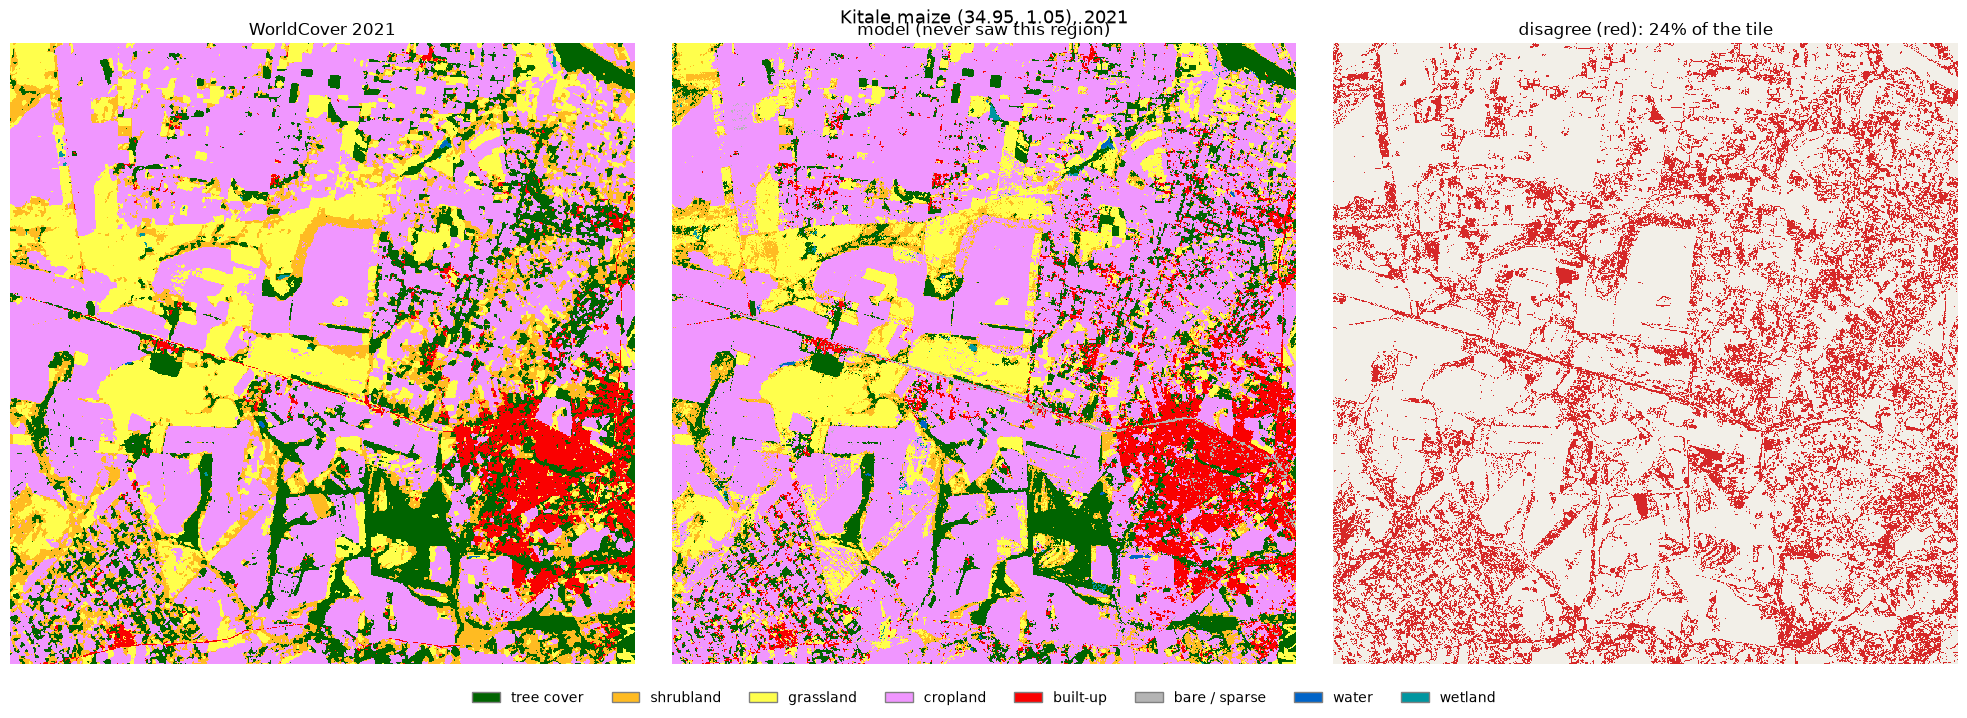

Kitale maize: satellite imagery https://www.google.com/maps/@1.05000,34.95000,15z/data=!3m1!1e3


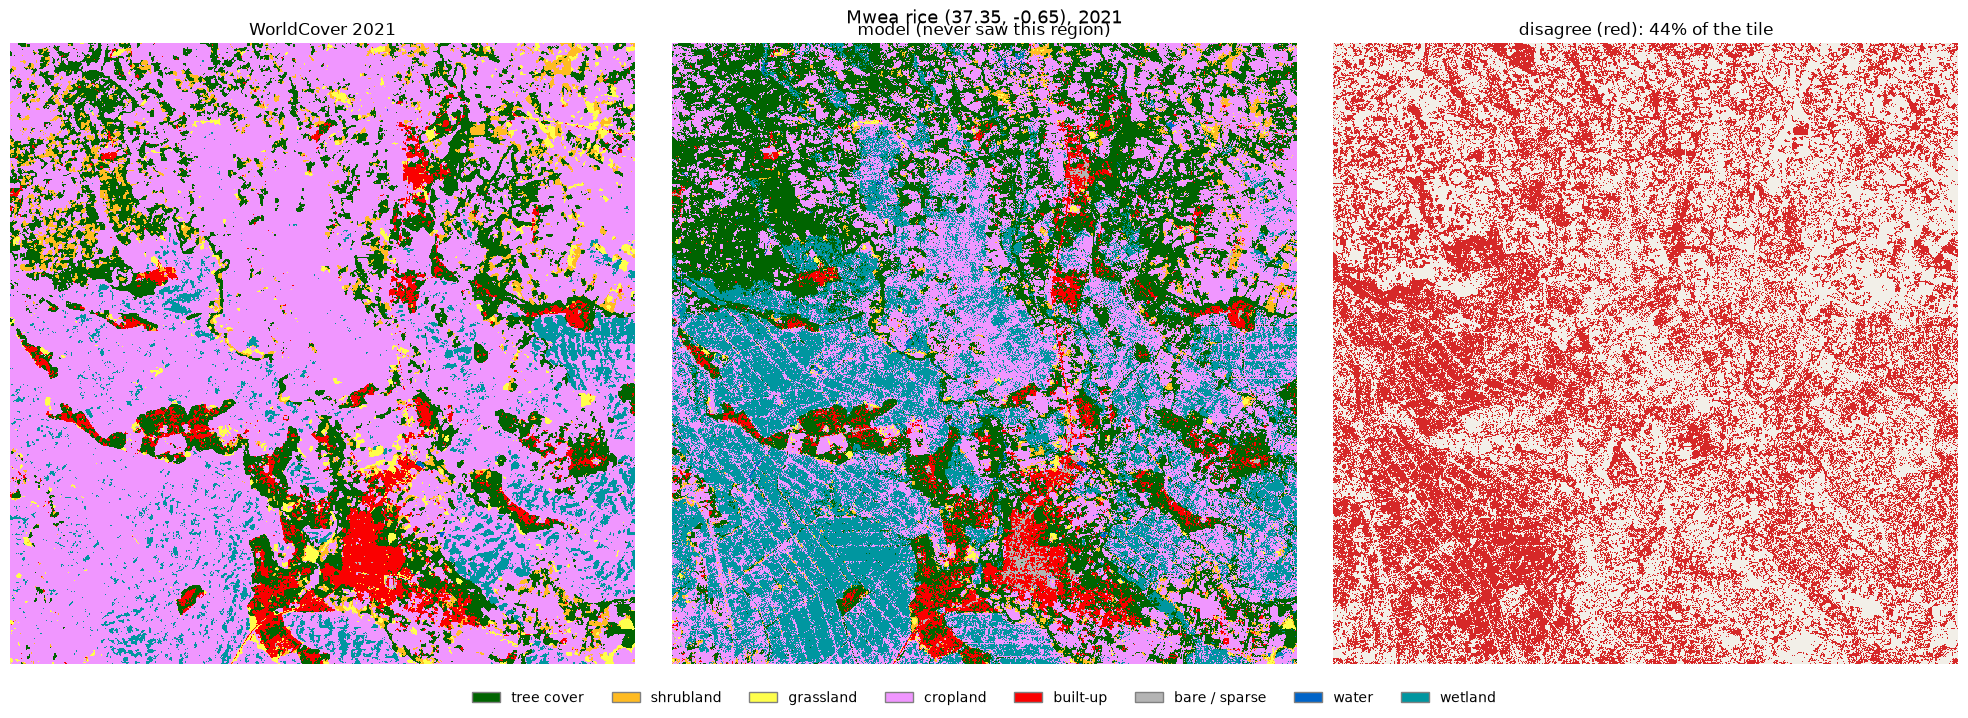

Mwea rice: satellite imagery https://www.google.com/maps/@-0.65000,37.35000,15z/data=!3m1!1e3


In [7]:
# ---------------------------------------------------------------------------
# FULL-TILE MAPS FROM THE HELD-OUT MODELS
# ---------------------------------------------------------------------------
def predict_tile(region, lon, lat):
    emb, crs, transform = K.fetch(gt, lon, lat, YEAR)
    h, w, d = emb.shape
    wc = labels_on_grid(lon, lat, crs, transform, (h, w))
    pred = models[region].predict(emb.reshape(-1, d)).reshape(h, w).astype(np.uint8)
    pred[~K.valid_mask(emb)] = 0
    return wc, pred

legend = [Patch(fc=CLASSES[c][1], ec="0.5", label=CLASSES[c][0]) for c in CODES]
for region in ("Kitale maize", "Mwea rice"):
    lon, lat = REGIONS[region][0]
    wc, pred = predict_tile(region, lon, lat)
    differs = (wc != pred) & np.isin(wc, CODES) & (pred > 0)
    fig, axes = plt.subplots(1, 3, figsize=(20, 7.2))
    for ax, img, title in zip(axes[:2], (wc, pred), ("WorldCover 2021", "model (never saw this region)")):
        ax.imshow(to_index(img), cmap=CMAP, vmin=0, vmax=len(CODES), interpolation="nearest")
        ax.set_title(title, fontsize=12); ax.axis("off")
    axes[2].imshow(differs, cmap=ListedColormap(["#f2efe8", "#d62828"]), interpolation="nearest")
    axes[2].set_title(f"disagree (red): {differs.mean():.0%} of the tile", fontsize=12)
    axes[2].axis("off")
    fig.legend(handles=legend, loc="lower center", ncol=8, frameon=False, fontsize=10)
    fig.suptitle(f"{region} {(lon, lat)}, 2021", fontsize=13)
    plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()
    print(f"{region}: satellite imagery {K.gmaps(lon, lat)}")

**Kitale** (24% disagreement): the model reproduces the large fields, the town
and the tree lines. The disagreement sits mostly in the fragmented smallholder
patchwork, where a 10 m pixel often mixes a field edge, a hedge and a house.

**Mwea** (44% disagreement): the model calls most of the **rice paddies
wetland**. WorldCover itself labels some of them wetland (the teal stripes on
the right of its map). With Mwea held out, the model's only examples of
wetland come from elsewhere, and a flooded paddy looks like a marsh. That is a
disagreement about definitions as much as an error.

## 6. How much cropland?

The number a policy user would actually want: the share of each region that is
cropland, by WorldCover and by the model trained without that region.

                 cropland_wc  cropland_model
region                                      
Mwea rice              66.7%           36.9%
Kitale maize           47.0%           56.4%
Uasin Gishu            41.5%           36.7%
Rift escarpment        11.1%           16.3%
Nairobi                 2.8%            4.3%
Konza                   2.3%            1.8%
Kericho tea             1.0%            2.9%
Lake Baringo            0.8%            3.7%
Mau Forest              0.4%            1.6%
Maasai Mara             0.1%            1.0%
Marsabit desert         0.0%            0.0%


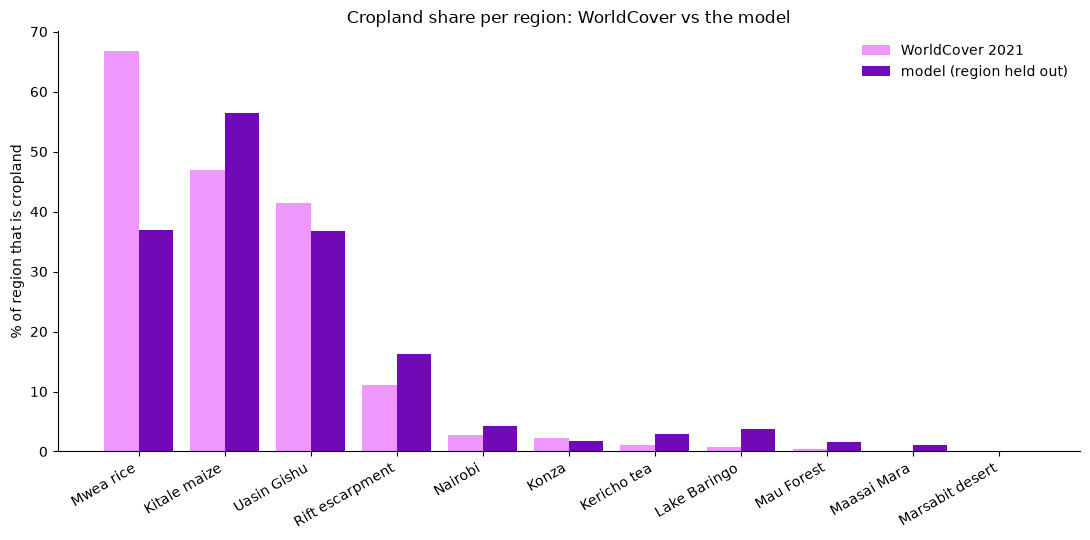

In [8]:
# ---------------------------------------------------------------------------
# CROPLAND SHARE PER REGION
# ---------------------------------------------------------------------------
crop = per_region[["cropland_wc", "cropland_model"]].sort_values("cropland_wc", ascending=False)
print(crop.to_string(float_format=lambda v: f"{v:6.1%}"))

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(crop))
ax.bar(x - 0.2, 100 * crop.cropland_wc, 0.4, color="#f096ff", label="WorldCover 2021")
ax.bar(x + 0.2, 100 * crop.cropland_model, 0.4, color="#7209b7", label="model (region held out)")
ax.set_xticks(x); ax.set_xticklabels(crop.index, rotation=30, ha="right")
ax.set_ylabel("% of region that is cropland")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False)
ax.set_title("Cropland share per region: WorldCover vs the model", fontsize=12)
plt.tight_layout(); plt.show()

In the two big maize and wheat regions, the model's cropland share is close to
WorldCover's: **Kitale 56% vs 47%**, **Uasin Gishu 37% vs 42%**. Everywhere else
both say very little cropland. The one large gap is **Mwea (37% vs 67%)**, the
paddies-as-wetland effect above.

Remember what the answer key misses: in Kenya, WorldCover's 2020 version found
only about a third of the cropland that field checks found. A model trained on
it inherits that. Matching WorldCover's cropland share is agreement, not proof
of a correct cropland area.


## 7. What this notebook establishes

1. **A linear model on TESSERA embeddings reproduces WorldCover at 68.6% in
   regions it has never seen** (macro F1 0.61), against WorldCover's own global
   accuracy of 76.7%. No feature engineering: 128 numbers per pixel, one
   logistic regression.

2. **It transfers across Kenya.** Holding out whole regions costs 4.3 points
   against the easy test, so most of what it learns carries over to new places.

3. **Clear classes are easy, blurry ones are not.** Water, bare ground, tree
   cover, built-up and cropland agree 71–86% of the time. Shrubland (54%) and
   wetland (50%) are where WorldCover's own categories blur.

4. **The labels limit the result more than the embeddings do.** WorldCover
   labels Kericho's tea as tree cover, and at Mwea it splits rice paddies
   between cropland and wetland. The model follows the labels it is given.

**Limits, stated plainly:**

- **Agreement, not accuracy.** There is no field-checked answer key here, and
  in Kenya WorldCover misses about two-thirds of cropland (Kerner et al.). The
  Kenya field dataset from that study has 573 points nationwide, too few in
  these 24 tiles to use.
- **24 tiles in 11 regions**: the western and central highlands, the Rift,
  and around Nairobi, plus one desert tile in the north. No coast, no
  mangroves. A national map would need training
  tiles from those too.
- **One year (2021)**, matched to WorldCover's year.
- **The honest next step for cropland** is a field-checked dataset, not a
  better model: the embeddings separate what WorldCover separates, and can only
  be judged against something truer than WorldCover.
